Modelo estrella

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 📁 AJUSTA esta ruta a donde está tu .db en tu Drive
SRC_DB = "/content/drive/MyDrive/proyect_SECOP_datos_ultimo_año.db"

# Dónde escribir la BD destino (puede ser en Drive también)
DST_DB = "/content/drive/MyDrive/secop_star.db"

SOURCE_TABLE = "contratos"  # <-- AJUSTA al nombre real de tu tabla en la base origen


inspeccion rapida del esquema de origen

In [6]:
import sqlite3, pandas as pd

src = sqlite3.connect(SRC_DB)
# Ver tablas
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", src)
display(tables)

# Ver columnas de la tabla principal
cols = pd.read_sql_query(f"PRAGMA table_info({SOURCE_TABLE});", src)
display(cols)

src.close()


,name
0,D_Categoria
1,D_Entidad
2,D_Modalidad
3,D_Proveedor
4,D_Tiempo
5,D_TipoContrato
6,D_UbiEntidad
7,D_UbiProveedor
8,F_Proceso


,cid,name,type,notnull,dflt_value,pk


Inspección: columnas y llaves foráneas

In [9]:
# Si ya tienes `conn` abierto, lo reutiliza. Si no, descomenta la siguiente línea y ajusta la ruta:
# import sqlite3; conn = sqlite3.connect("/content/drive/MyDrive/Proyect_SECOP_datos_ultimo_año.db")

import pandas as pd

# Detectar tablas
tables_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
tables = [t for t in tables_df["name"].tolist() if not t.startswith("sqlite_")]

# Identificar hecho(s) y dimensiones por prefijo
facts = sorted([t for t in tables if t.upper().startswith("F_")])
dims  = sorted([t for t in tables if t.upper().startswith("D_")])

# Elegir el hecho principal (prioriza F_Proceso si existe)
FACT = "F_Proceso" if "F_Proceso" in tables else (facts[0] if facts else None)
DIMS = dims

print("FACT =", FACT)
print("DIMS =", DIMS)

if FACT is None:
    raise ValueError("No se encontró ninguna tabla de hecho (prefijo F_). Revisa los nombres de tus tablas.")


FACT = F_Proceso
DIMS = ['D_Categoria', 'D_Entidad', 'D_Modalidad', 'D_Proveedor', 'D_Tiempo', 'D_TipoContrato', 'D_UbiEntidad', 'D_UbiProveedor']


In [10]:
print("Tablas:")
display(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn))

print("Esquema del hecho (F_Proceso):")
display(pd.read_sql_query(f"PRAGMA table_info('{FACT}');", conn))

print("Llaves foráneas del hecho (F_Proceso):")
fk = pd.read_sql_query(f"PRAGMA foreign_key_list('{FACT}');", conn)
display(fk)

print("Esquemas de dimensiones:")
for t in DIMS:
    print(f"==== {t} ====")
    display(pd.read_sql_query(f"PRAGMA table_info('{t}');", conn))


Tablas:


,name
0,D_Categoria
1,D_Entidad
2,D_Modalidad
3,D_Proveedor
4,D_Tiempo
5,D_TipoContrato
6,D_UbiEntidad
7,D_UbiProveedor
8,F_Proceso


Esquema del hecho (F_Proceso):


,cid,name,type,notnull,dflt_value,pk
0,0,id_del_proceso,TEXT,0,None,1
1,1,id_adjudicacion,TEXT,0,None,0
2,2,precio_base,REAL,0,None,0
3,3,valor_total_adjudicacion,REAL,0,None,0
4,4,numero_de_lotes,INTEGER,0,None,0
5,5,proveedores_invitados,INTEGER,0,None,0
6,6,respuestas_al_procedimiento,INTEGER,0,None,0
7,7,visualizaciones_del,INTEGER,0,None,0
8,8,entidad_id,INTEGER,0,None,0
9,9,proveedor_id,INTEGER,0,None,0


Llaves foráneas del hecho (F_Proceso):


...

,cid,name,type,notnull,dflt_value,pk
0,0,tipo_contrato_id,INTEGER,0,None,1
1,1,tipo_de_contrato,TEXT,0,None,0
2,2,subtipo_de_contrato,TEXT,0,None,0


==== D_UbiEntidad ====


,cid,name,type,notnull,dflt_value,pk
0,0,ubi_entidad_id,INTEGER,0,None,1
1,1,departamento_entidad,TEXT,0,None,0
2,2,ciudad_entidad,TEXT,0,None,0


==== D_UbiProveedor ====


,cid,name,type,notnull,dflt_value,pk
0,0,ubi_proveedor_id,INTEGER,0,None,1
1,1,departamento_proveedor,TEXT,0,None,0
2,2,ciudad_proveedor,TEXT,0,None,0


Crear la vista vw_proceso_full con todos los JOINs

In [11]:
sql_view = """
CREATE VIEW IF NOT EXISTS vw_proceso_full AS
SELECT
  -- Hecho
  f.id_del_proceso,
  f.id_adjudicacion,
  f.precio_base,
  f.valor_total_adjudicacion,
  f.numero_de_lotes,
  f.proveedores_invitados,
  f.respuestas_al_procedimiento,
  f.visualizaciones_del,
  f.estado_del_procedimiento,
  f.id_estado_del_procedimiento,

  -- Entidad (quedémonos con campos más útiles)
  e.entidad                               AS entidad,
  e.codigo_entidad                        AS codigo_entidad,
  e.ordenentidad                          AS orden_entidad,
  e.codigo_pci                            AS codigo_pci,
  e.nombre_de_la_unidad_de                AS unidad_entidad,

  -- Ubicación de la entidad
  ue.departamento_entidad                 AS dpto_entidad,
  ue.ciudad_entidad                       AS mpio_entidad,

  -- Proveedor
  p.nit                                   AS proveedor_nit,
  p.nombre_del_proveedor                  AS proveedor_nombre,

  -- Ubicación del proveedor
  up.departamento_proveedor               AS dpto_proveedor,
  up.ciudad_proveedor                     AS mpio_proveedor,

  -- Modalidad y tipo de contrato
  m.modalidad_de_contratacion             AS modalidad,
  tc.tipo_de_contrato                     AS tipo_contrato,
  tc.subtipo_de_contrato                  AS subtipo_contrato,

  -- Categoría
  c.codigo_principal_de_categoria         AS unspsc,

  -- Tiempo
  t.fecha                                 AS fecha,
  t."año"                                 AS anio,
  t.trimestre                             AS trimestre,
  t.mes                                   AS mes,
  t."día"                                 AS dia

FROM F_Proceso f
LEFT JOIN D_Entidad      e  ON f.entidad_id       = e.entidad_id
LEFT JOIN D_UbiEntidad   ue ON f.ubi_entidad_id   = ue.ubi_entidad_id
LEFT JOIN D_Proveedor    p  ON f.proveedor_id     = p.proveedor_id
LEFT JOIN D_UbiProveedor up ON f.ubi_proveedor_id = up.ubi_proveedor_id
LEFT JOIN D_Modalidad    m  ON f.modalidad_id     = m.modalidad_id
LEFT JOIN D_TipoContrato tc ON f.tipo_contrato_id = tc.tipo_contrato_id
LEFT JOIN D_Categoria    c  ON f.categoria_id     = c.categoria_id
LEFT JOIN D_Tiempo       t  ON f.tiempo_id        = t.tiempo_id;
"""
conn.executescript(sql_view)
conn.commit()
print("Vista creada: vw_proceso_full")

# Ver 5 filas de muestra
pd.read_sql_query("SELECT * FROM vw_proceso_full LIMIT 5;", conn)


Vista creada: vw_proceso_full


,id_del_proceso,id_adjudicacion,precio_base,valor_total_adjudicacion,numero_de_lotes,proveedores_invitados,respuestas_al_procedimiento,visualizaciones_del,estado_del_procedimiento,id_estado_del_procedimiento,...,mpio_proveedor,modalidad,tipo_contrato,subtipo_contrato,unspsc,fecha,anio,trimestre,mes,dia
0,CO1.REQ.1456251,No Adjudicado,96000000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Otro,No Definido,V1.86101600,2025-04-01,2025,2,4,1
1,CO1.REQ.2520241,No Adjudicado,90000000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Decreto 092 de 2017,No Definido,V1.85101600,2025-02-24,2025,1,2,24
2,CO1.REQ.3268070,No Adjudicado,2856000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Decreto 092 de 2017,No Definido,V1.84131516,2025-08-07,2025,3,8,7
3,CO1.REQ.3437388,No Adjudicado,6914000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación directa,Prestación de servicios,No Definido,V1.80101604,2025-08-13,2025,3,8,13
4,CO1.REQ.3437587,No Adjudicado,6914000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación directa,Prestación de servicios,No Definido,V1.80101604,2025-08-13,2025,3,8,13


Índices sobre FKs del hecho

In [12]:
conn.executescript("""
CREATE INDEX IF NOT EXISTS idx_f_entidad        ON F_Proceso(entidad_id);
CREATE INDEX IF NOT EXISTS idx_f_proveedor      ON F_Proceso(proveedor_id);
CREATE INDEX IF NOT EXISTS idx_f_tiempo         ON F_Proceso(tiempo_id);
CREATE INDEX IF NOT EXISTS idx_f_ubi_entidad    ON F_Proceso(ubi_entidad_id);
CREATE INDEX IF NOT EXISTS idx_f_ubi_proveedor  ON F_Proceso(ubi_proveedor_id);
CREATE INDEX IF NOT EXISTS idx_f_categoria      ON F_Proceso(categoria_id);
CREATE INDEX IF NOT EXISTS idx_f_modalidad      ON F_Proceso(modalidad_id);
CREATE INDEX IF NOT EXISTS idx_f_tipocontrato   ON F_Proceso(tipo_contrato_id);
""")
conn.commit()
print("Índices creados (si faltaban).")


Índices creados (si faltaban).


Checks rapidos

In [13]:
# Conteos por tabla
pd.read_sql_query("""
SELECT 'F_Proceso' AS tabla, COUNT(*) AS n FROM F_Proceso
UNION ALL SELECT 'D_Categoria', COUNT(*) FROM D_Categoria
UNION ALL SELECT 'D_Entidad', COUNT(*) FROM D_Entidad
UNION ALL SELECT 'D_Modalidad', COUNT(*) FROM D_Modalidad
UNION ALL SELECT 'D_Proveedor', COUNT(*) FROM D_Proveedor
UNION ALL SELECT 'D_Tiempo', COUNT(*) FROM D_Tiempo
UNION ALL SELECT 'D_TipoContrato', COUNT(*) FROM D_TipoContrato
UNION ALL SELECT 'D_UbiEntidad', COUNT(*) FROM D_UbiEntidad
UNION ALL SELECT 'D_UbiProveedor', COUNT(*) FROM D_UbiProveedor;
""", conn)


,tabla,n
0,F_Proceso,1434181
1,D_Categoria,11937
2,D_Entidad,18411
3,D_Modalidad,44
4,D_Proveedor,482720
5,D_Tiempo,276
6,D_TipoContrato,23
7,D_UbiEntidad,1106
8,D_UbiProveedor,1495


In [14]:
# Huérfanos por cada FK (debería dar 0 si las FKs están consistentes)
fk = pd.read_sql_query("PRAGMA foreign_key_list('F_Proceso');", conn)
reps = []
for _, r in fk.iterrows():
    dim, from_col, to_col = r["table"], r["from"], r["to"]
    q = f"""
    SELECT COUNT(*) AS orphans
    FROM F_Proceso f
    LEFT JOIN {dim} d ON f.{from_col} = d.{to_col}
    WHERE f.{from_col} IS NOT NULL AND d.{to_col} IS NULL;
    """
    n = pd.read_sql_query(q, conn).iloc[0,0]
    reps.append({"fk": f"F_Proceso.{from_col} -> {dim}.{to_col}", "orphans": int(n)})
pd.DataFrame(reps)


,fk,orphans
0,F_Proceso.tipo_contrato_id -> D_TipoContrato.t...,0
1,F_Proceso.modalidad_id -> D_Modalidad.modalida...,0
2,F_Proceso.categoria_id -> D_Categoria.categori...,0
3,F_Proceso.ubi_proveedor_id -> D_UbiProveedor.u...,0
4,F_Proceso.ubi_entidad_id -> D_UbiEntidad.ubi_e...,0
5,F_Proceso.tiempo_id -> D_Tiempo.tiempo_id,0
6,F_Proceso.proveedor_id -> D_Proveedor.proveedo...,0
7,F_Proceso.entidad_id -> D_Entidad.entidad_id,0


Consultas tipicas (analitica)

In [15]:
pd.read_sql_query("""
SELECT entidad, SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10;
""", conn)


,entidad,total
0,ESE HOSPITAL LOCAL CARTAGENA DE INDIAS.*,1.053169e+18
1,ALCALDIA MUNICIPAL DE PUENTE NACIONAL,2.197695e+16
2,POLITECNICO COLOMBIANO JAIME ISAZA CADAVID,8.308684e+15
3,IMDERCOR,6.514266e+15
4,ESTABLECIMIENTO PENITENCIARIO DE MEDIANA SEGUR...,1.547536e+15
5,INSTITUTO COLOMBIANO AGROPECUARIO - ICA SECCIO...,3.568241e+13
6,DISTRITO ESPECIAL DE CIENCIA TECNOLOGIA E INNO...,6.538069e+12
7,UNIDAD ADMINISTRATIVA ESPECIAL DE ORGANIZACION...,4.054088e+12
8,MUNICIPIO DE YUMBO VALLE,3.419322e+12
9,DEPARTAMENTO DE SANTANDER,2.943184e+12


Top 10 proveedores por valor_total_adjudicacion

In [16]:
pd.read_sql_query("""
SELECT proveedor_nombre, SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10;
""", conn)


,proveedor_nombre,total
0,HEALTH CARS SAS,1.053169e+18
1,CENTRO DE BIENESTAR DEL ADULTO MAYOR HOGAR SAN...,2.197695e+16
2,SUMINISTROS Y ELEMENTOS EMPRESARIALES S.A.S,8.308678e+15
3,FUNDACIÓN PARA LA INNOVACIÓN DE LAS CIENCIAS D...,6.514267e+15
4,M A S - UNION EMPRESARIAL SAS,1.547536e+15
5,SANDESOL S.A E.S.P,3.568246e+13
6,Fundación Remanso de Paz,4.045177e+12
7,FUNDACION AVANZAR SOCIAL,3.277492e+12
8,TERMINALES DE TRANSPORTE DE MEDELLIN S.A.,3.071538e+12
9,INSTITUTO FINANCIERO PARA EL DESARROLLO DE SAN...,2.604479e+12


Totales por modalidad

In [17]:
pd.read_sql_query("""
SELECT modalidad, SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY 1
ORDER BY 2 DESC;
""", conn)


,modalidad,total
0,Contratación régimen especial (con ofertas),1.081678e+18
1,Selección abreviada subasta inversa,8.312576e+15
2,Mínima cuantía,1.587611e+15
3,Contratación Directa (con ofertas),2.296501e+13
4,Selección Abreviada de Menor Cuantía,8.581627e+12
5,Licitación pública Obra Publica,6.733059e+12
6,Licitación pública,4.923677e+12
7,Concurso de méritos abierto,1.389273e+12
8,Seleccion Abreviada Menor Cuantia Sin Manifest...,5.815723e+11
9,Enajenación de bienes con sobre cerrado,1.282859e+10


Totales por tipo y subtipo de contrato

In [18]:
pd.read_sql_query("""
SELECT tipo_contrato, subtipo_contrato, SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY 1,2
ORDER BY 3 DESC;
""", conn)


,tipo_contrato,subtipo_contrato,total
0,Prestación de servicios,No Definido,1.053219e+18
1,Decreto 092 de 2017,No Definido,2.850537e+16
2,Suministros,No Definido,9.864305e+15
3,Otro,No Definido,2.130708e+13
4,Obra,No Definido,9.530423e+12
5,Compraventa,No Definido,1.947992e+12
6,Consultoría,No Definido,7.214944e+11
7,Interventoría,No Definido,7.034513e+11
8,Seguros,No Definido,5.380209e+11
9,Negocio fiduciario,No Definido,3.027922e+11


Serie mensual (año/mes)

In [19]:
pd.read_sql_query("""
SELECT anio, mes, SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY anio, mes
ORDER BY anio, mes;
""", conn)


,anio,mes,total
0,2025,1,3.443207e+12
1,2025,2,7.875287e+12
2,2025,3,1.560022e+15
3,2025,4,4.136736e+13
4,2025,5,2.850461e+16
5,2025,6,8.316485e+15
6,2025,7,1.053175e+18
7,2025,8,9.462766e+12
8,2025,9,4.962352e+12
9,2025,10,7.159430e+10


Métricas de competencia y “descuento”

In [20]:
pd.read_sql_query("""
SELECT
  AVG(respuestas_al_procedimiento)                       AS avg_respuestas,
  AVG(proveedores_invitados)                              AS avg_invitados,
  AVG(CASE WHEN proveedores_invitados > 0
           THEN 1.0*respuestas_al_procedimiento/proveedores_invitados END) AS avg_tasa_respuesta,
  AVG(CASE WHEN precio_base > 0
           THEN 1.0 - (valor_total_adjudicacion/precio_base) END) AS avg_descuento
FROM vw_proceso_full;
""", conn)


,avg_respuestas,avg_invitados,avg_tasa_respuesta,avg_descuento
0,0.0,23.364484,0.0,-283455.29855


Estado del procedimiento

In [21]:
pd.read_sql_query("""
SELECT estado_del_procedimiento, COUNT(*) AS procesos,
       SUM(valor_total_adjudicacion) AS total
FROM vw_proceso_full
GROUP BY 1
ORDER BY 2 DESC;
""", conn)


,estado_del_procedimiento,procesos,total
0,Seleccionado,784298,1.069645e+18
1,Publicado,572539,2.465113e+10
2,Evaluación,58556,3.445631e+11
3,Cancelado,11302,2.197765e+16
4,Abierto,5063,7.450766e+11
5,Borrador,1027,5.116991e+09
6,En aprobación,687,2.491395e+10
7,Aprobado,669,0.000000e+00
8,Suspendido,40,0.000000e+00


Materializar la vista

In [22]:
conn.executescript("""
DROP TABLE IF EXISTS T_ProcesoFull;
CREATE TABLE T_ProcesoFull AS
SELECT * FROM vw_proceso_full;
""")
conn.commit()
print("Tabla materializada: T_ProcesoFull")

Tabla materializada: T_ProcesoFull


# **Analisis univariado**

Tipado y listas de columnas

In [33]:
# 🔎 Autodetección de DB + fuente + carga en df
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sqlite3, pandas as pd, numpy as np, glob, os
from pathlib import Path

# 1) Buscar .db en tu Drive (ajusta la raíz si lo tienes en otra carpeta)
cands = sorted(glob.glob("/content/drive/MyDrive/**/*.db", recursive=True))
if not cands:
    raise FileNotFoundError("No encontré archivos .db en tu Drive. Revisa la ruta o sube el archivo.")

print("Candidatos .db encontrados:")
for i, p in enumerate(cands):
    print(f"{i:>2} • {p}")

# 2) Elegir el .db que contenga 'vw_proceso_full' o al menos una F_* (prioridad alta)
def has_obj(conn, name):
    return not pd.read_sql_query(
        "SELECT 1 FROM sqlite_master WHERE (type='table' OR type='view') AND name=? LIMIT 1;",
        conn, params=(name,)
    ).empty

def list_names(conn):
    return pd.read_sql_query("SELECT name, type FROM sqlite_master WHERE type IN ('table','view')", conn)

best_db, reason = None, ""
for p in cands:
    try:
        conn = sqlite3.connect(p); rows = list_names(conn)
        names = rows["name"].str.upper().tolist()
        if "VW_PROCESO_FULL" in names:
            best_db, reason = p, "tiene vw_proceso_full"; conn.close(); break
        if any(n.startswith("F_") for n in names):
            best_db, reason = p, "tiene tabla F_*"; conn.close(); break
        conn.close()
    except Exception:
        pass

# fallback: tomar el primero si no halló coincidencias fuertes
if best_db is None:
    best_db, reason = cands[0], "fallback (primero encontrado)"

print(f"\nDB elegido: {best_db}  <- {reason}")

# 3) Elegir la fuente (prioriza vista, luego cualquier F_*, luego algo con 'PROCESO', si no, la tabla más grande)
conn = sqlite3.connect(best_db)
names_df = list_names(conn)
tables = names_df[names_df["type"]=="table"]["name"].tolist()
views  = names_df[names_df["type"]=="view"]["name"].tolist()
upper_tables = [t.upper() for t in tables]

if "vw_proceso_full" in views:
    SOURCE = "vw_proceso_full"
elif any(t.upper().startswith("F_") for t in tables):
    SOURCE = next(t for t in tables if t.upper().startswith("F_"))
elif any("PROCESO" in t.upper() for t in tables):
    SOURCE = next(t for t in tables if "PROCESO" in t.upper())
else:
    # tabla más grande por conteo rápido
    sizes = []
    for t in tables:
        try:
            n = pd.read_sql_query(f'SELECT COUNT(*) n FROM "{t}"', conn).iloc[0,0]
        except Exception:
            n = -1
        sizes.append((n, t))
    sizes.sort(reverse=True)
    SOURCE = sizes[0][1] if sizes and sizes[0][0] >= 0 else tables[0]

print(f"Fuente elegida: {SOURCE}")

# 4) Cargar
df = pd.read_sql_query(f'SELECT * FROM "{SOURCE}"', conn)
conn.close()
print("Shape:", df.shape)
df.head(3)


Mounted at /content/drive
Candidatos .db encontrados:
 0 • /content/drive/MyDrive/Proyect_SECOP_datos_ultimo_año.db
 1 • /content/drive/MyDrive/proyect_SECOP_datos_ultimo_año.db

DB elegido: /content/drive/MyDrive/proyect_SECOP_datos_ultimo_año.db  <- tiene vw_proceso_full
Fuente elegida: vw_proceso_full
Shape: (1434181, 30)


,id_del_proceso,id_adjudicacion,precio_base,valor_total_adjudicacion,numero_de_lotes,proveedores_invitados,respuestas_al_procedimiento,visualizaciones_del,estado_del_procedimiento,id_estado_del_procedimiento,...,mpio_proveedor,modalidad,tipo_contrato,subtipo_contrato,unspsc,fecha,anio,trimestre,mes,dia
0,CO1.REQ.1456251,No Adjudicado,96000000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Otro,No Definido,V1.86101600,2025-04-01,2025,2,4,1
1,CO1.REQ.2520241,No Adjudicado,90000000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Decreto 092 de 2017,No Definido,V1.85101600,2025-02-24,2025,1,2,24
2,CO1.REQ.3268070,No Adjudicado,2856000.0,0.0,0,0,0,0,Publicado,50,...,No Definido,Contratación régimen especial,Decreto 092 de 2017,No Definido,V1.84131516,2025-08-07,2025,3,8,7


In [34]:
import pandas as pd, numpy as np

# Tipado rápido
df2 = df.copy()
for c in df2.columns:
    if df2[c].dtype == "O":
        df2[c] = pd.to_numeric(df2[c], errors="ignore")
date_cols = [c for c in df2.columns if c.lower() in ("fecha","date")]
for c in date_cols:
    df2[c] = pd.to_datetime(df2[c], errors="coerce")

num_cols = sorted(df2.select_dtypes(include=[np.number]).columns.tolist())
cat_cols = sorted([c for c in df2.columns if c not in num_cols and c not in date_cols])

# Resumen numérico (describe + %missing + outliers IQR)
def num_summary(df_, cols):
    if not cols: return pd.DataFrame()
    desc = df_[cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
    miss = df_[cols].isna().sum().rename("missing")
    miss_pct = (100*df_[cols].isna().mean()).rename("missing_%")
    q1 = df_[cols].quantile(.25, numeric_only=True)
    q3 = df_[cols].quantile(.75, numeric_only=True)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    out_lo = (df_[cols].lt(low)).sum().rename("outliers_lo")
    out_hi = (df_[cols].gt(high)).sum().rename("outliers_hi")
    return pd.concat([desc, miss, miss_pct, out_lo, out_hi], axis=1).sort_values("missing_%", ascending=False)

num_summary_df = num_summary(df2, num_cols)

# Resumen categórico (top-5)
def cat_summary(df_, cols, k=5):
    n = len(df_)
    rows = []
    for c in cols:
        s = df_[c]
        vc = s.value_counts(dropna=False)
        top = vc.head(k)
        top_str = " | ".join([f"{str(i)}: {int(v)} ({(v/n*100):.1f}%)" for i, v in top.items()])
        rows.append({
            "col": c,
            "count": n,
            "missing": int(s.isna().sum()),
            "missing_%": round(100*s.isna().mean(),2),
            "unique": int(s.nunique(dropna=True)),
            "top_values": top_str
        })
    return pd.DataFrame(rows).sort_values(["missing_%","unique"], ascending=[False, True]).reset_index(drop=True)

cat_summary_df = cat_summary(df2, cat_cols)

# Fechas (si existen)
if date_cols:
    c = date_cols[0]
    fecha_summary = pd.DataFrame({
        "col":[c],
        "min":[df2[c].min()], "max":[df2[c].max()],
        "count":[df2[c].notna().sum()], "missing":[df2[c].isna().sum()]
    })
else:
    fecha_summary = pd.DataFrame()

print("\n▶️ Resumen NUMÉRICO"); display(num_summary_df)
print("\n▶️ Resumen CATEGÓRICO (top-5)"); display(cat_summary_df.head(30))
if not fecha_summary.empty:
    print("\n▶️ Resumen FECHA"); display(fecha_summary)


/tmp/ipython-input-2034666861.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2[c] = pd.to_numeric(df2[c], errors="ignore")



▶️ Resumen NUMÉRICO


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_%,outliers_lo,outliers_hi
anio,1434181.0,2.025000e+03,0.000000e+00,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,2.025000e+03,2.025000e+03,0,0.0,0,0
codigo_entidad,1434181.0,7.055084e+08,5.852243e+06,700000011.0,700090079.0,700509136.0,702046087.0,703688838.0,705555407.0,718660053.0,7.233962e+08,7.333467e+08,0,0.0,0,226430
dia,1434181.0,1.552107e+01,8.812207e+00,1.0,1.0,2.0,8.0,15.0,23.0,29.0,3.100000e+01,3.100000e+01,0,0.0,0,0
id_estado_del_procedimiento,1434181.0,6.160999e+01,1.016362e+01,0.0,50.0,50.0,50.0,70.0,70.0,70.0,7.000000e+01,1.000000e+02,0,0.0,79,0
mes,1434181.0,4.695515e+00,2.758212e+00,1.0,1.0,1.0,2.0,4.0,7.0,9.0,1.000000e+01,1.000000e+01,0,0.0,0,0
numero_de_lotes,1434181.0,3.974603e-02,8.946499e-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,1.620000e+02,0,0.0,0,12055
precio_base,1434181.0,1.908158e+10,2.264279e+13,-32372000.0,0.0,1000000.0,6900000.0,15638337.0,35000000.0,220000000.0,1.718153e+09,2.711639e+16,0,0.0,0,162744
proveedores_invitados,1434181.0,2.336448e+01,2.815545e+02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.810000e+02,1.563200e+04,0,0.0,0,40245
respuestas_al_procedimiento,1434181.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0,0.0,0,0
trimestre,1434181.0,1.920358e+00,8.754757e-01,1.0,1.0,1.0,1.0,2.0,3.0,3.0,4.000000e+00,4.000000e+00,0,0.0,0,0



▶️ Resumen CATEGÓRICO (top-5)


,col,count,missing,missing_%,unique,top_values
0,subtipo_contrato,1434181,0,0.0,1,No Definido: 1434181 (100.0%)
1,codigo_pci,1434181,0,0.0,2,Centralizada: 854580 (59.6%) | Descentralizada...
2,orden_entidad,1434181,0,0.0,4,Territorial: 1017161 (70.9%) | Nacional: 39610...
3,estado_del_procedimiento,1434181,0,0.0,9,Seleccionado: 784298 (54.7%) | Publicado: 5725...
4,modalidad,1434181,0,0.0,16,Contratación régimen especial: 687509 (47.9%) ...
5,tipo_contrato,1434181,0,0.0,23,Prestación de servicios: 956248 (66.7%) | Decr...
6,dpto_entidad,1434181,0,0.0,34,Distrito Capital de Bogotá: 323143 (22.5%) | A...
7,dpto_proveedor,1434181,0,0.0,129,No Definido: 660795 (46.1%) | Distrito Capital...
8,mpio_entidad,1434181,0,0.0,992,No Definido: 236619 (16.5%) | Bogotá: 189571 (...
9,mpio_proveedor,1434181,0,0.0,1063,No Definido: 721689 (50.3%) | Bogotá: 133739 (...



▶️ Resumen FECHA


,col,min,max,count,missing
0,fecha,2025-01-01,2025-10-03,1434181,0


##########################################################################

In [42]:
# Celda 0: instalar libs y cargar df desde tu .db


from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sqlite3, pandas as pd, numpy as np, glob, os
from pathlib import Path

# === Config === (si sabes la ruta exacta, ponla aquí y se usará tal cual)
SRC_DB = "/content/drive/MyDrive/Proyect_SECOP_datos_ultimo_año.db"   # <- cambia si tu archivo está en otra carpeta
OUT_DIR = "/content/drive/MyDrive/secop_out"
os.makedirs(OUT_DIR, exist_ok=True)

def pick_db():
    p = Path(SRC_DB)
    if p.exists():
        return str(p)
    # buscar cualquier .db en MyDrive
    cands = sorted(glob.glob("/content/drive/MyDrive/**/*.db", recursive=True))
    if not cands:
        raise FileNotFoundError("No encontré archivos .db en tu Drive (MyDrive). Ajusta SRC_DB o sube el archivo.")
    # elegir el que tenga vista o tabla esperada
    for cand in cands:
        try:
            conn = sqlite3.connect(cand)
            names = pd.read_sql_query("SELECT name, type FROM sqlite_master WHERE type IN ('view','table')", conn)
            if "vw_proceso_full" in names['name'].tolist():
                conn.close(); return cand
            if any(n.upper().startswith("F_") for n in names['name']):
                conn.close(); return cand
            conn.close()
        except:
            pass
    return cands[0]

DB_PATH = pick_db()
print("DB:", DB_PATH)

def pick_source(conn):
    names = pd.read_sql_query("SELECT name, type FROM sqlite_master WHERE type IN ('view','table')", conn)
    tables = names[names["type"]=="table"]["name"].tolist()
    views  = names[names["type"]=="view"]["name"].tolist()
    if "vw_proceso_full" in views:
        return "vw_proceso_full"
    f_tabs = [t for t in tables if t.upper().startswith("F_")]
    if f_tabs:
        return f_tabs[0]
    proc = [t for t in tables if "PROCESO" in t.upper()]
    if proc:
        return proc[0]
    # tabla más grande
    sizes = []
    for t in tables:
        try:
            n = pd.read_sql_query(f'SELECT COUNT(*) n FROM "{t}"', conn).iloc[0,0]
        except:
            n = -1
        sizes.append((n,t))
    sizes.sort(reverse=True)
    return sizes[0][1]

conn = sqlite3.connect(DB_PATH)
SOURCE = pick_source(conn)
print("Fuente:", SOURCE)
df = pd.read_sql_query(f'SELECT * FROM "{SOURCE}"', conn)
conn.close()
print("Shape df:", df.shape)
display(df.head(3))

# Tipado ligero + detección de tipos
X = df.copy()
for c in X.columns:
    if X[c].dtype == "O":
        X[c] = pd.to_numeric(X[c], errors="ignore")

# Fechas: columna 'fecha' o 'date' si existe
date_cols = [c for c in X.columns if c.lower() in ("fecha", "date")]
for c in date_cols:
    X[c] = pd.to_datetime(X[c], errors="coerce")

num_cols = sorted(X.select_dtypes(include=[np.number]).columns.tolist())
cat_cols = sorted([c for c in X.columns if c not in num_cols and c not in date_cols])

print("Numéricas:", len(num_cols), "| Categóricas:", len(cat_cols), "| Fechas:", date_cols)


Mounted at /content/drive
DB: /content/drive/MyDrive/Proyect_SECOP_datos_ultimo_año.db


IndexError: list index out of range

Analisis Univariado

/tmp/ipython-input-599813437.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": skew(s), "kurt": kurtosis(s),


,col,count,missing,mean,median,std,min,p01,p05,p25,...,p75,p95,p99,max,skew,kurt,iqr_low,iqr_high,outliers_lo,outliers_hi
0,anio,1434181,0,2.025000e+03,2025.0,0.000000e+00,2025.0,2025.0,2025.0,2025.0,...,2025.0,2025.0,2.025000e+03,2.025000e+03,NaN,NaN,2025.0,2025.0,0,0
1,codigo_entidad,1434181,0,7.055084e+08,703688838.0,5.852243e+06,700000011.0,700090079.0,700509136.0,702046087.0,...,705555407.0,718660053.0,7.233962e+08,7.333467e+08,1.711944,2.067875e+00,696782107.0,710819387.0,0,226430
2,dia,1434181,0,1.552107e+01,15.0,8.812207e+00,1.0,1.0,2.0,8.0,...,23.0,29.0,3.100000e+01,3.100000e+01,0.043316,-1.203778e+00,-14.5,45.5,0,0
3,id_estado_del_procedimiento,1434181,0,6.160999e+01,70.0,1.016362e+01,0.0,50.0,50.0,50.0,...,70.0,70.0,7.000000e+01,1.000000e+02,0.119549,-3.732670e-01,20.0,100.0,79,0
4,mes,1434181,0,4.695515e+00,4.0,2.758212e+00,1.0,1.0,1.0,2.0,...,7.0,9.0,1.000000e+01,1.000000e+01,0.186542,-1.311751e+00,-5.5,14.5,0,0
5,numero_de_lotes,1434181,0,3.974603e-02,0.0,8.946499e-01,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,1.620000e+02,65.517306,6.439830e+03,0.0,0.0,0,12055
6,precio_base,1434181,0,1.908158e+10,15638337.0,2.264279e+13,-32372000.0,0.0,1000000.0,6900000.0,...,35000000.0,220000000.0,1.718153e+09,2.711639e+16,1197.571546,1.434176e+06,-35250000.0,77150000.0,0,162744
7,proveedores_invitados,1434181,0,2.336448e+01,0.0,2.815545e+02,0.0,0.0,0.0,0.0,...,0.0,0.0,4.810000e+02,1.563200e+04,18.410652,4.196159e+02,0.0,0.0,0,40245
8,respuestas_al_procedimiento,1434181,0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,0,0
9,trimestre,1434181,0,1.920358e+00,2.0,8.754757e-01,1.0,1.0,1.0,1.0,...,3.0,3.0,4.000000e+00,4.000000e+00,0.260789,-1.397592e+00,-2.0,6.0,0,0


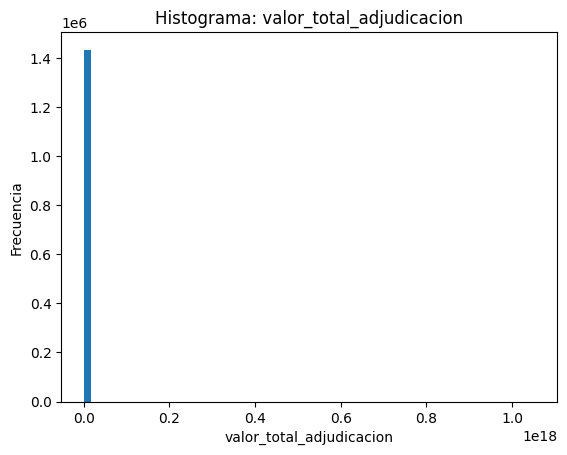

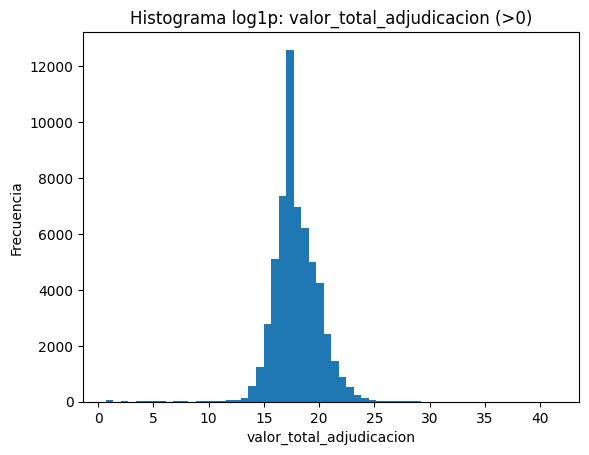

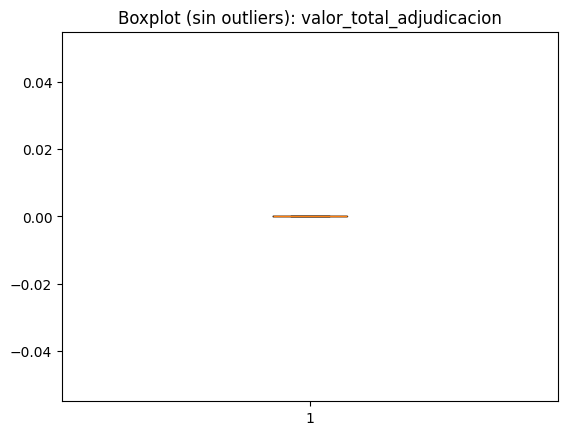

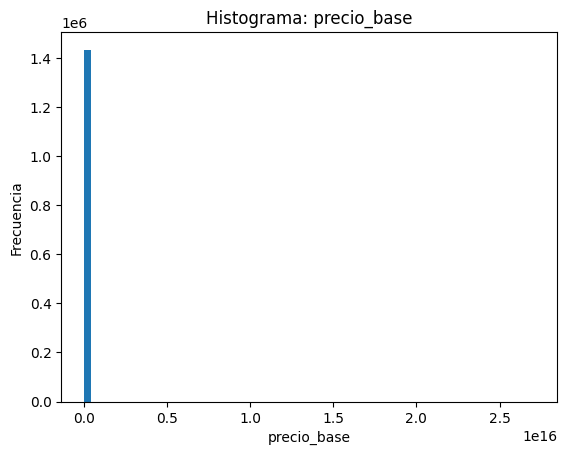

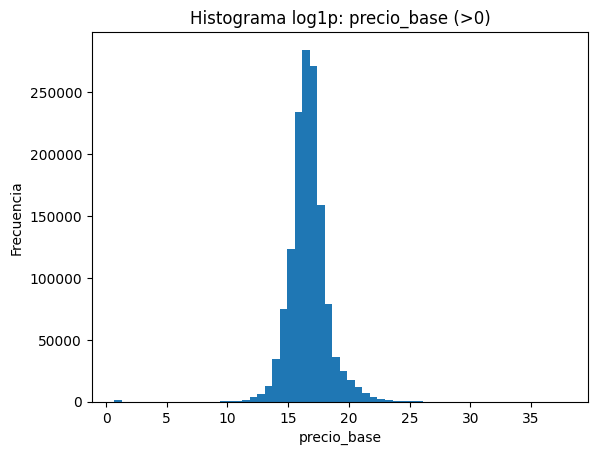

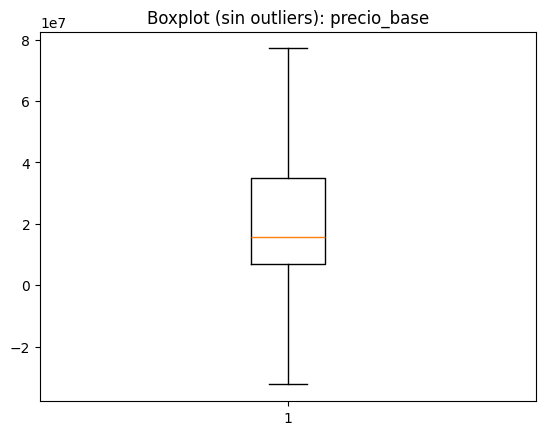

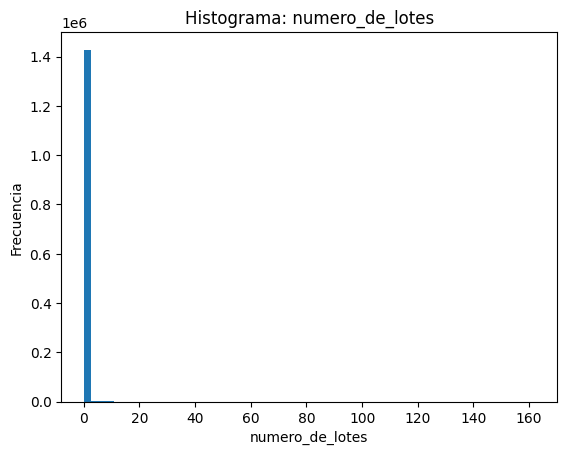

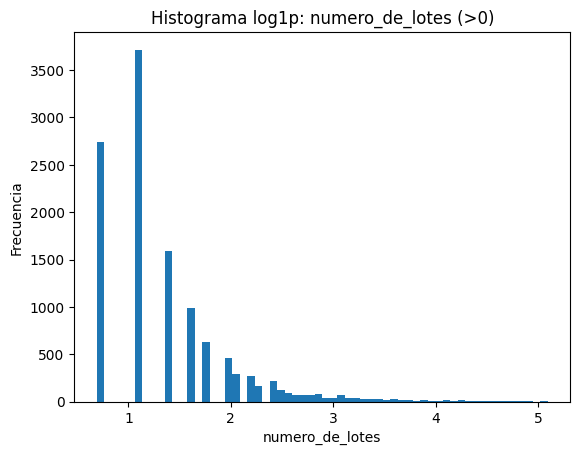

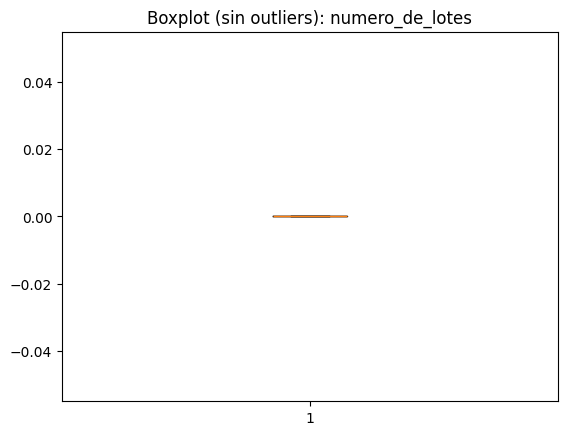

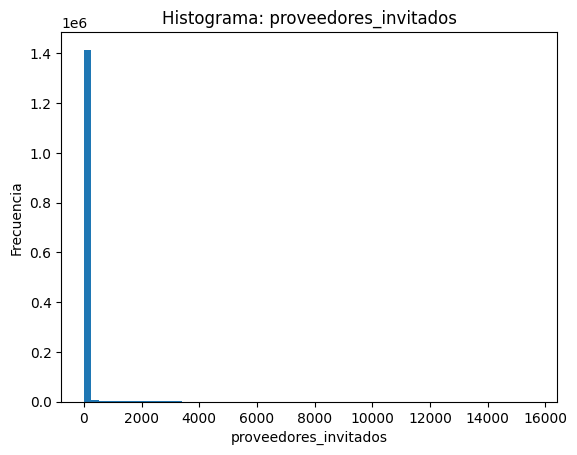

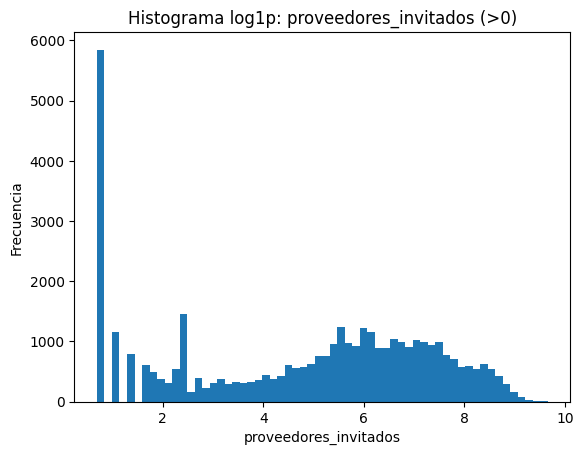

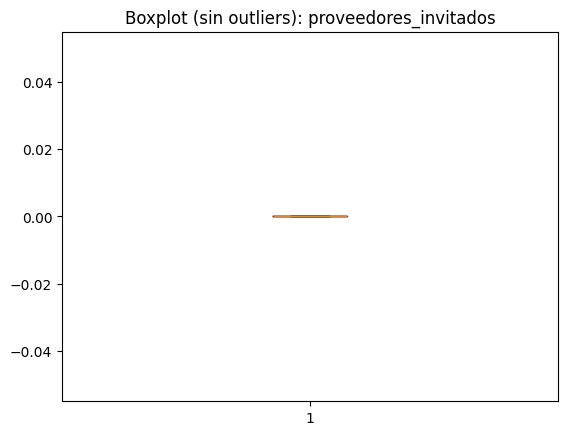

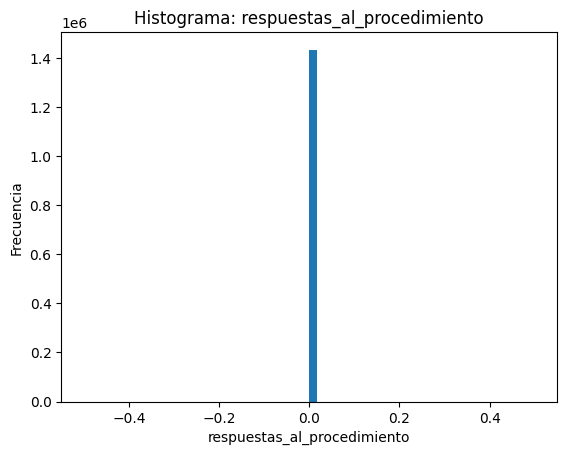

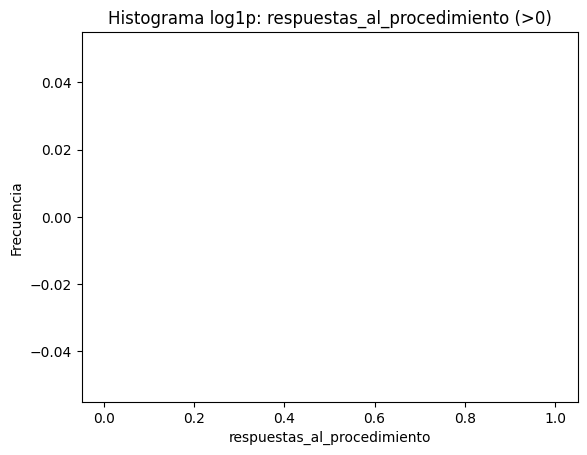

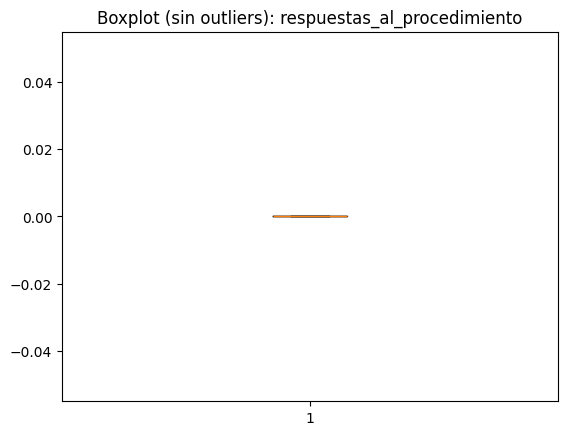

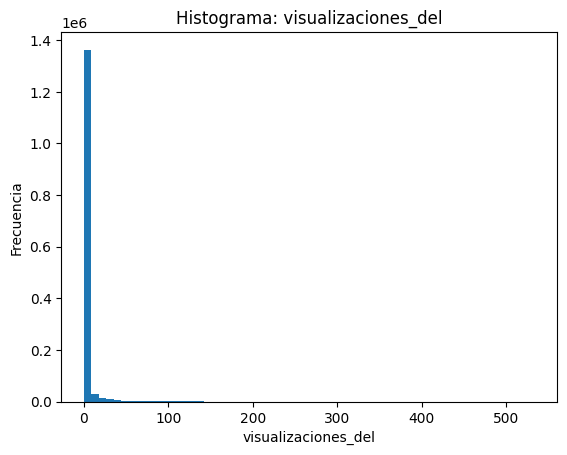

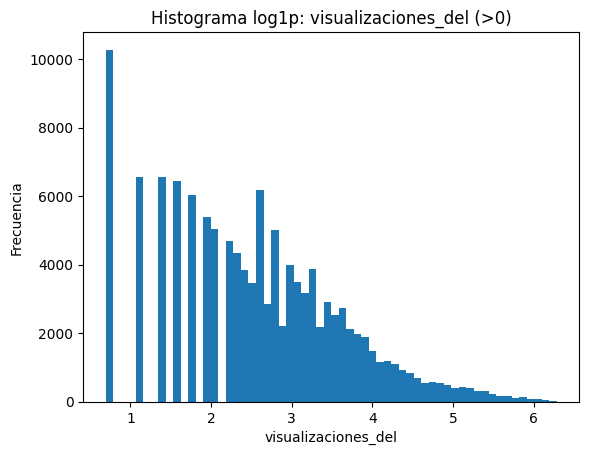

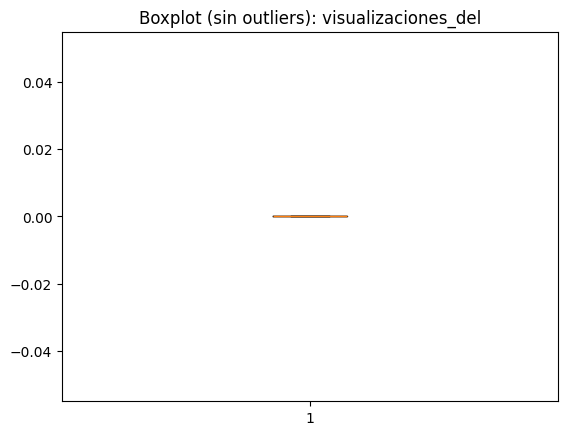

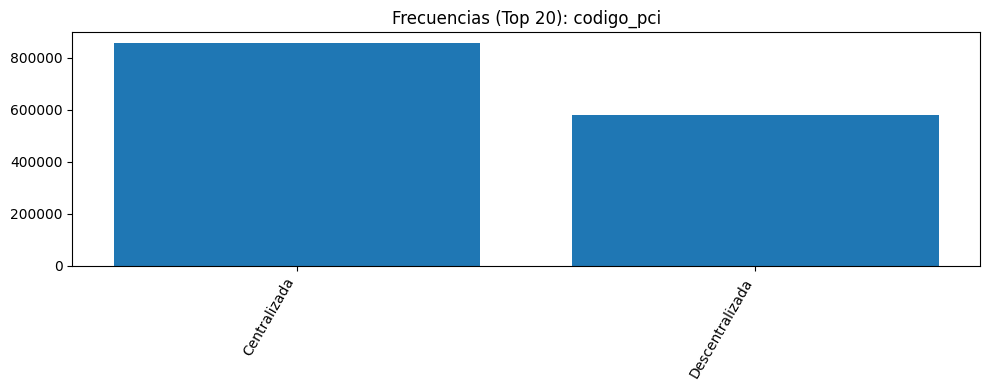

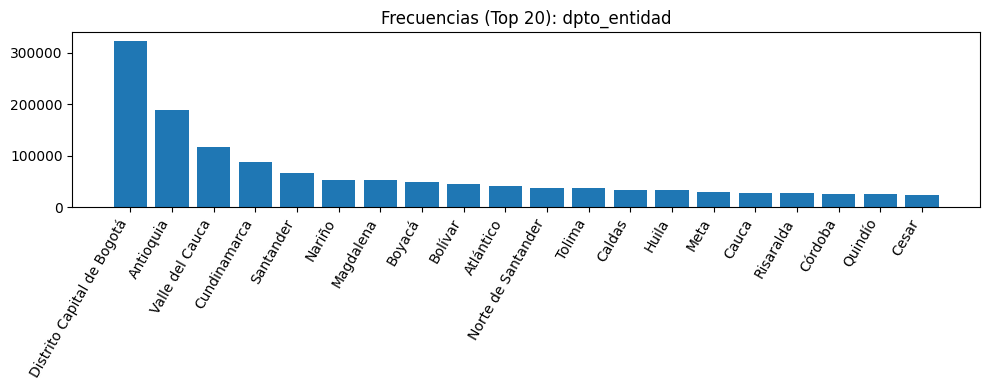

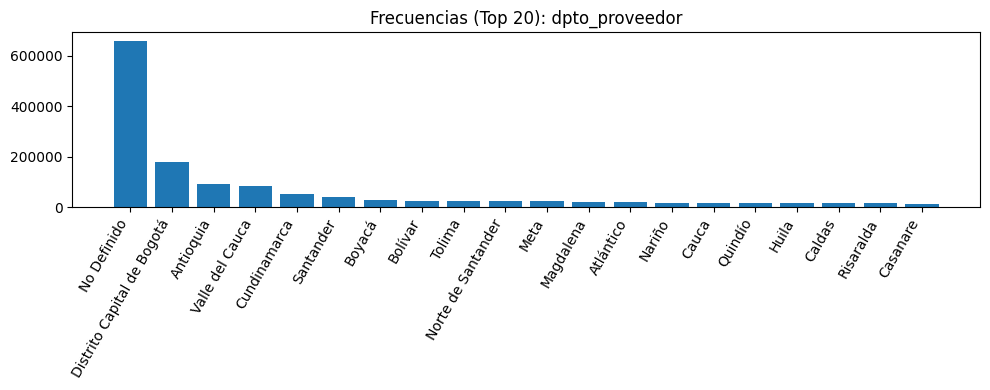

/tmp/ipython-input-599813437.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.xticks(rotation=60, ha="right"); plt.title(f"Frecuencias (Top 20): {c}"); plt.tight_layout(); plt.show()


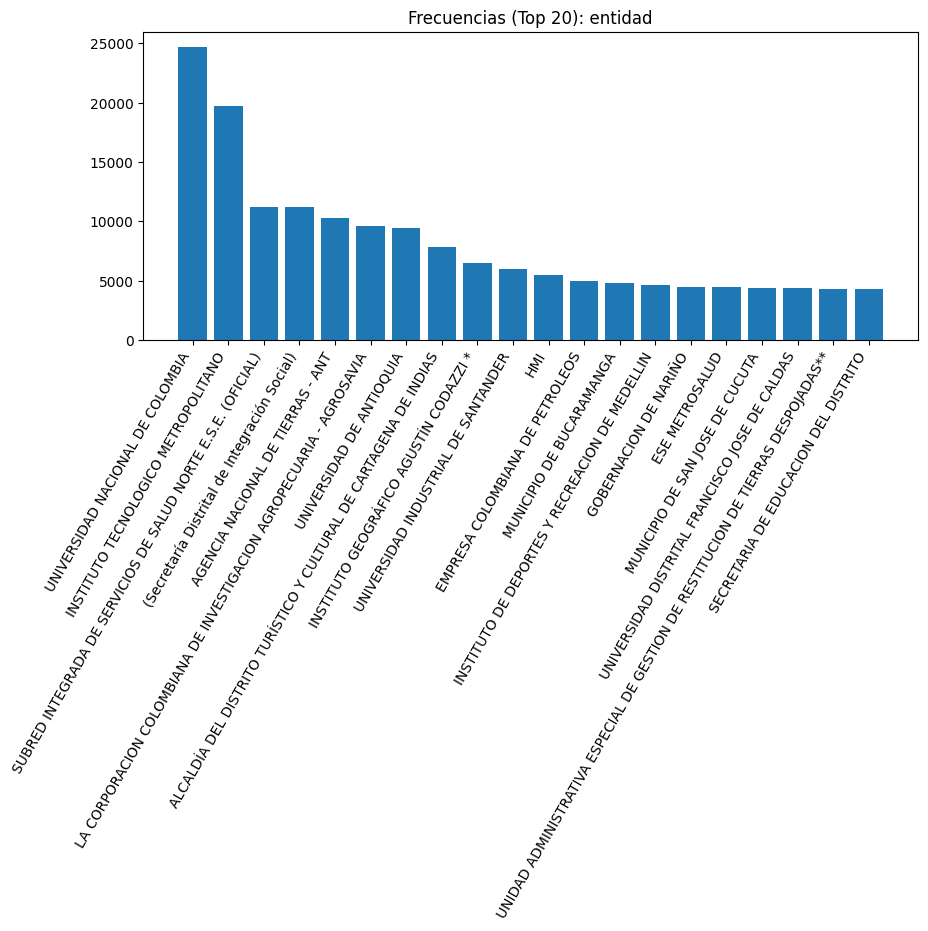

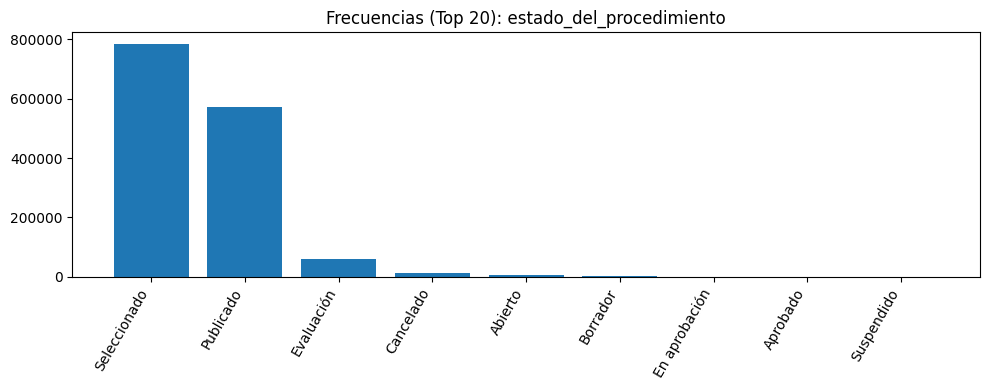

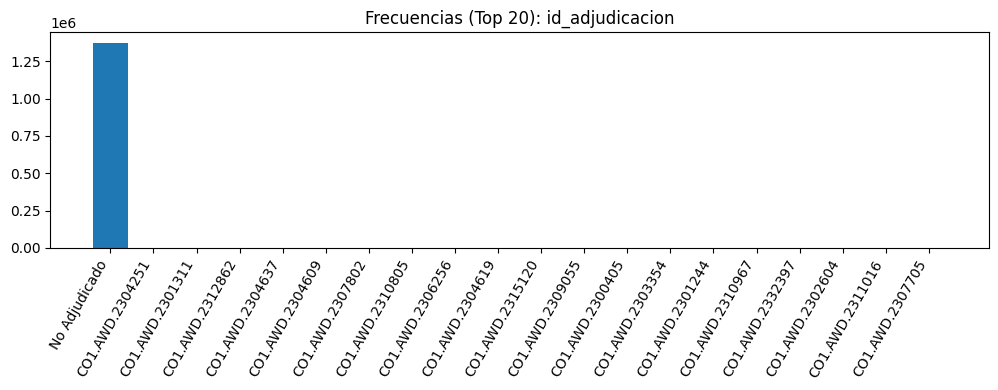

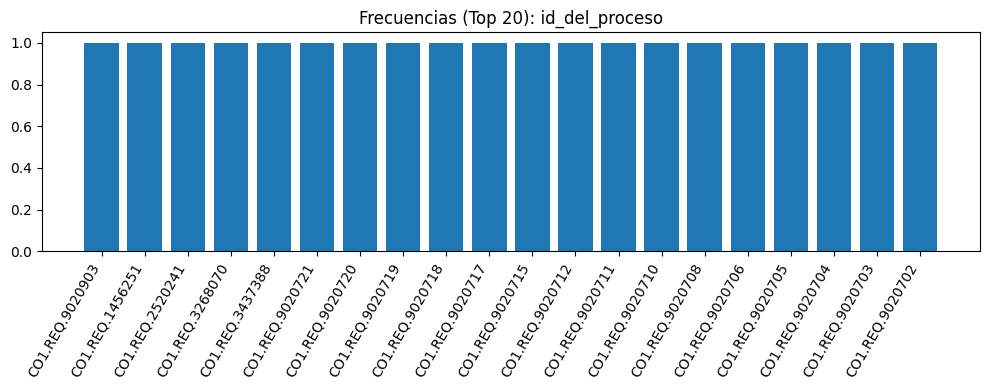

/tmp/ipython-input-599813437.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.xticks(rotation=60, ha="right"); plt.title(f"Frecuencias (Top 20): {c}"); plt.tight_layout(); plt.show()


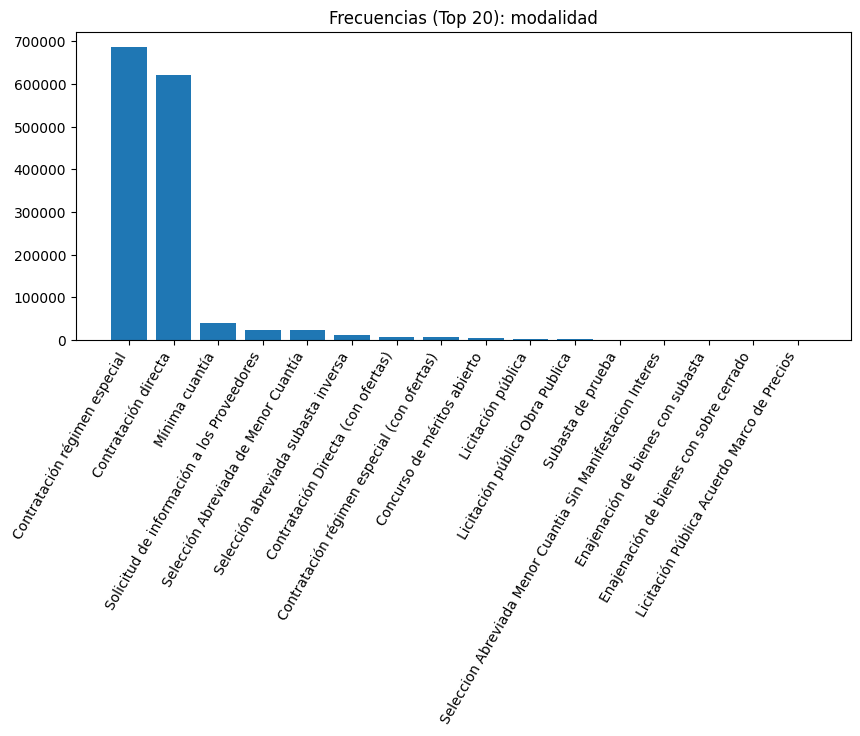

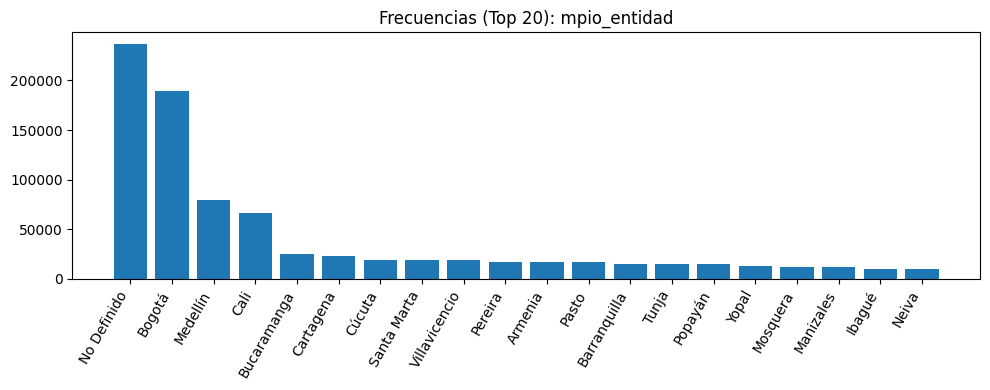

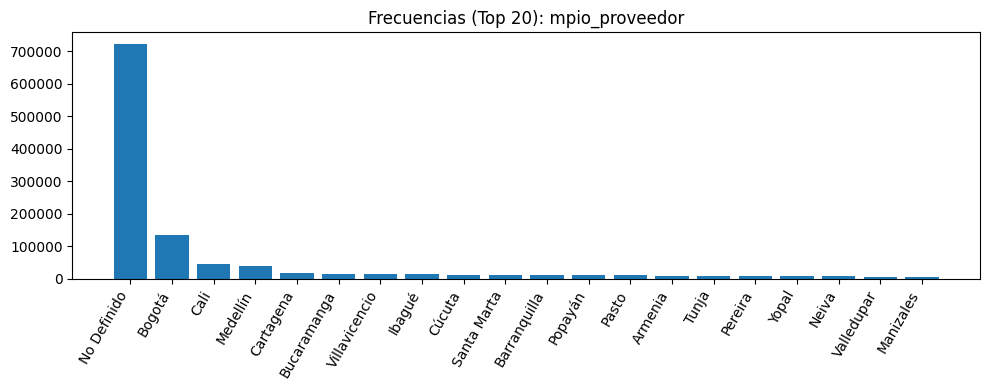

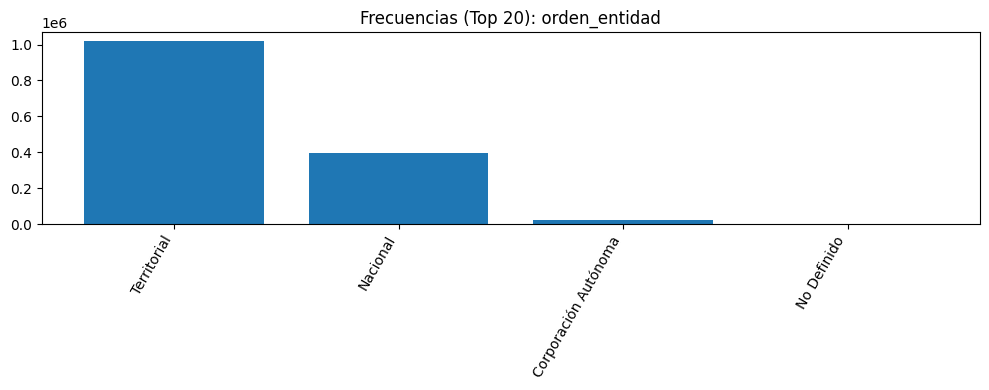

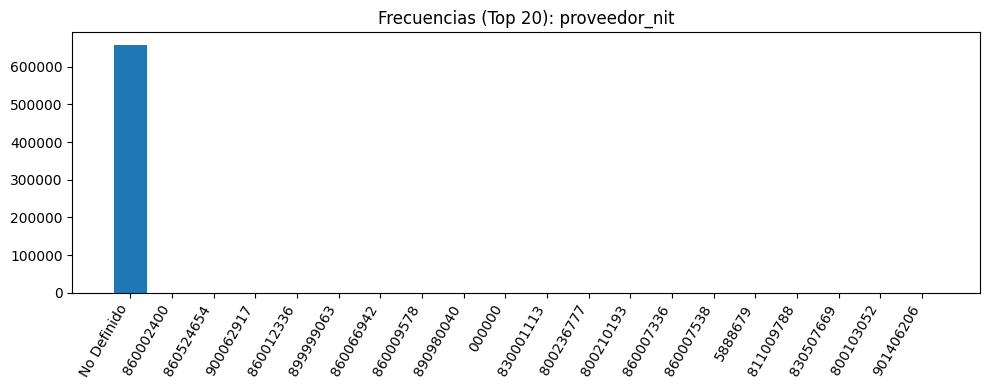

/tmp/ipython-input-599813437.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.xticks(rotation=60, ha="right"); plt.title(f"Frecuencias (Top 20): {c}"); plt.tight_layout(); plt.show()


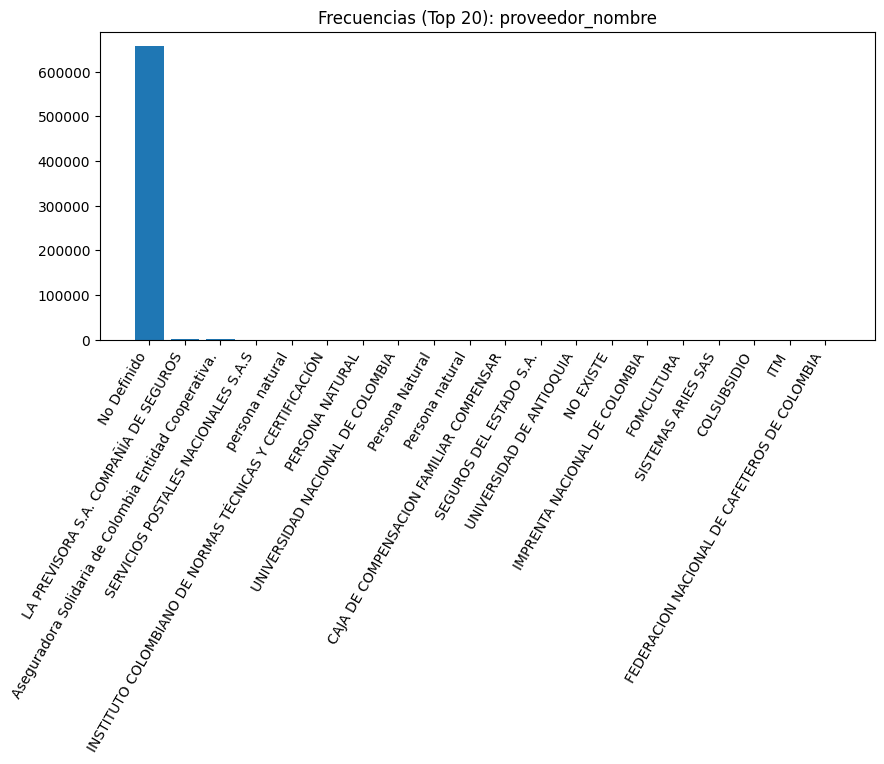

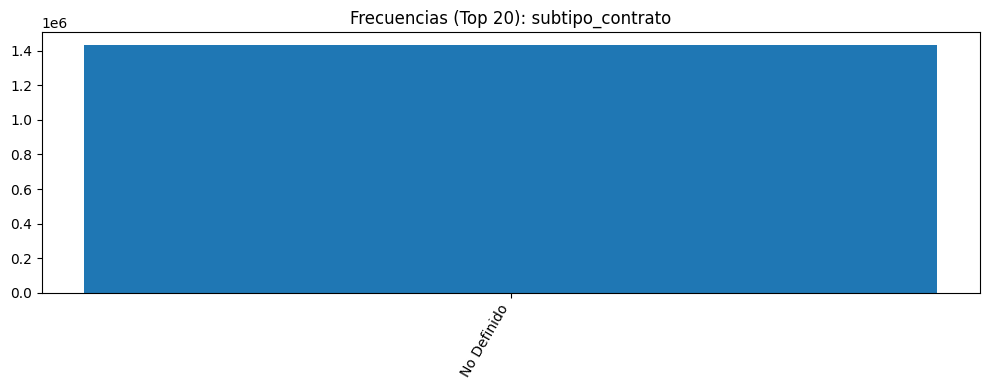

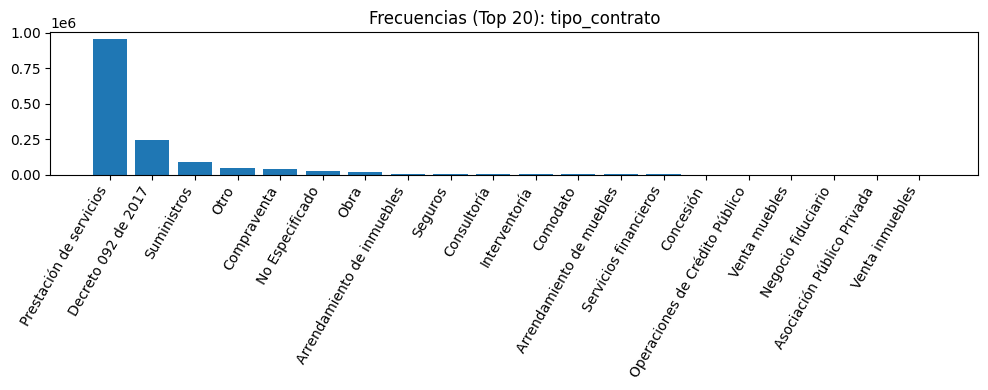

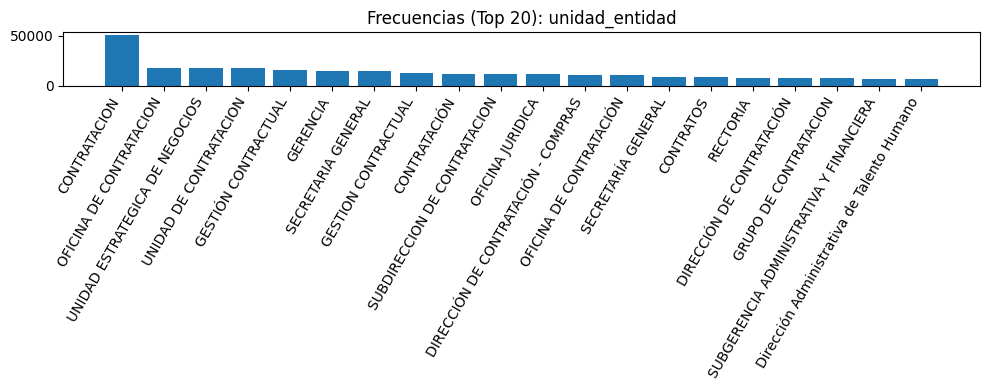

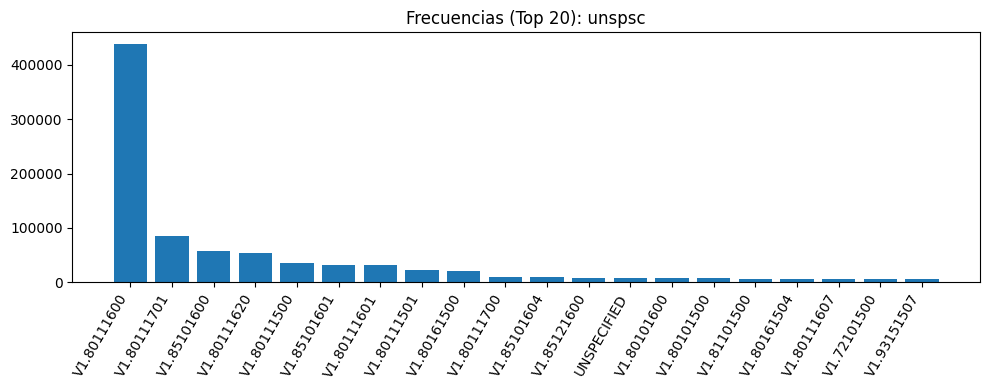

Temporal (fecha) -> count=1434181, min=2025-01-01, max=2025-10-03


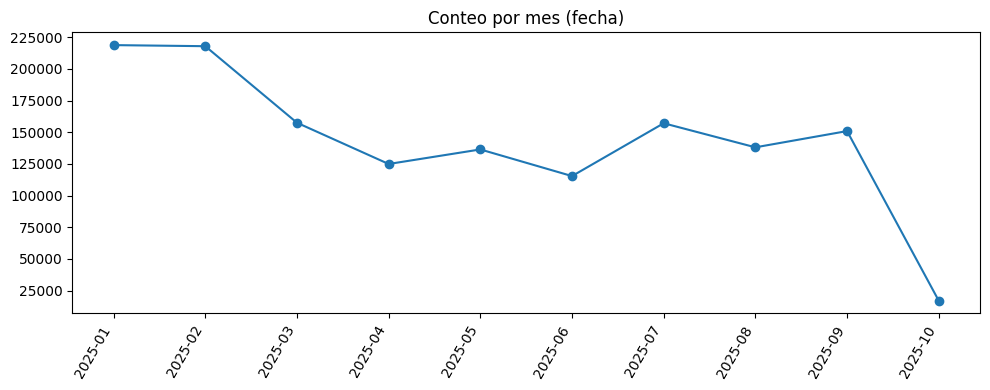

In [43]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# === Numéricas: tendencia central, dispersión, percentiles, outliers IQR ===
def univar_numericas(df_, cols):
    if not cols: return pd.DataFrame()
    out = []
    for c in cols:
        s = pd.to_numeric(df_[c], errors="coerce").dropna()
        if len(s)==0:
            out.append({"col":c,"count":0}); continue
        q = s.quantile([0, .01, .05, .25, .5, .75, .95, .99, 1.0])
        q1, q3 = q.loc[.25], q.loc[.75]
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        out.append({
          "col": c, "count": int(s.size), "missing": int(df_[c].isna().sum()),
          "mean": s.mean(), "median": s.median(), "std": s.std(),
          "min": q.loc[0.0], "p01": q.loc[.01], "p05": q.loc[.05], "p25": q.loc[.25],
          "p50": q.loc[.5], "p75": q.loc[.75], "p95": q.loc[.95], "p99": q.loc[.99], "max": q.loc[1.0],
          "skew": skew(s), "kurt": kurtosis(s),
          "iqr_low": low, "iqr_high": high,
          "outliers_lo": int((s<low).sum()), "outliers_hi": int((s>high).sum())
        })
    return pd.DataFrame(out).sort_values("missing", ascending=False)

num_uni = univar_numericas(X, num_cols)
display(num_uni.head(20))
num_uni.to_csv(f"{OUT_DIR}/univariado_numericas.csv", index=False)

# Visualizaciones: histogramas + boxplot (sin outliers) para hasta 6 columnas clave
cols_plot = [c for c in ["valor_total_adjudicacion","precio_base","numero_de_lotes",
                         "proveedores_invitados","respuestas_al_procedimiento","visualizaciones_del"]
             if c in num_cols]
if not cols_plot:
    cols_plot = num_cols[:6]

for c in cols_plot:
    s = pd.to_numeric(X[c], errors="coerce").dropna()
    if s.empty: continue
    plt.figure(); plt.hist(s, bins=60); plt.title(f"Histograma: {c}"); plt.xlabel(c); plt.ylabel("Frecuencia"); plt.show()
    plt.figure(); plt.hist(np.log1p(s[s>0]), bins=60); plt.title(f"Histograma log1p: {c} (>0)"); plt.xlabel(c); plt.ylabel("Frecuencia"); plt.show()
    plt.figure(); plt.boxplot(s, vert=True, showfliers=False); plt.title(f"Boxplot (sin outliers): {c}"); plt.show()

# === Categóricas: frec. absoluta, relativa, acumulada + gráfico barras (top 20) ===
def freq_table(s, top=None):
    vc = s.value_counts(dropna=False)
    if top: vc = vc.head(top)
    abs_f = vc.rename("abs")
    rel = (vc / vc.sum()).rename("rel")
    cum_abs = abs_f.cumsum().rename("cum_abs")
    cum_rel = rel.cumsum().rename("cum_rel")
    t = pd.concat([abs_f, rel, cum_abs, cum_rel], axis=1)
    return t.reset_index().rename(columns={"index": s.name})

cat_reports = {}
for c in cat_cols:
    t = freq_table(X[c], top=None)
    cat_reports[c] = t
    # gráfico top-20
    top20 = t.head(20)
    plt.figure(figsize=(10,4)); plt.bar(top20[c].astype(str), top20["abs"])
    plt.xticks(rotation=60, ha="right"); plt.title(f"Frecuencias (Top 20): {c}"); plt.tight_layout(); plt.show()

# Guardar las 30 primeras tablas como CSV
for i, (c, t) in enumerate(cat_reports.items()):
    if i>=30: break
    t.to_csv(f"{OUT_DIR}/freq_{i:02d}_{c}.csv", index=False)

# === Temporales: conteo, mínimo y máximo ===
if date_cols:
    dc = date_cols[0]
    s = X[dc].dropna()
    print(f"Temporal ({dc}) -> count={s.size}, min={s.min().date() if len(s) else None}, max={s.max().date() if len(s) else None}")
    # Serie por AAAA-MM
    ym = s.dt.to_period("M").value_counts().sort_index()
    plt.figure(figsize=(10,4)); plt.plot(ym.index.astype(str), ym.values, marker="o")
    plt.xticks(rotation=60, ha="right"); plt.title(f"Conteo por mes ({dc})"); plt.tight_layout(); plt.show()
    pd.DataFrame({"periodo": ym.index.astype(str), "n": ym.values}).to_csv(f"{OUT_DIR}/temporal_conteo_mensual.csv", index=False)


Univariado

Numéricas: media, mediana, std, percentiles, asimetría, curtosis, outliers IQR + histogramas/boxplots.

Categóricas: frecuencias (absoluta, relativa, acumulada) + barras top-20 (CSV por variable).

Temporales: conteo, min, max + serie mensual.

Bivariado (num–num, num–cat, cat–cat)

In [44]:
import pandas as pd, numpy as np
from math import sqrt
from scipy.stats import chi2_contingency

# === Num–Num: correlaciones (Pearson/Spearman) ===
def corr_top(df_, cols, method="pearson", k=20, min_n=50):
    if len(cols) < 2: return pd.DataFrame()
    sub = df_[cols]
    cmat = sub.corr(method=method, numeric_only=True)
    long = (cmat.where(~np.eye(cmat.shape[0], dtype=bool)).stack().reset_index())
    long.columns = ["var1","var2","corr"]
    long["pair"] = long.apply(lambda r: tuple(sorted([r.var1, r.var2])), axis=1)
    long = long.drop_duplicates("pair").drop(columns="pair")
    nmask = {col: sub[col].notna() for col in cols}
    long["n"] = long.apply(lambda r: int((nmask[r.var1] & nmask[r.var2]).sum()), axis=1)
    long["abs_corr"] = long["corr"].abs()
    long = long[long["n"] >= min_n].sort_values(["abs_corr","n"], ascending=False)
    return long.head(k)

pearson_top = corr_top(X, num_cols, "pearson", k=20, min_n=50)
spearman_top = corr_top(X, num_cols, "spearman", k=20, min_n=50)
print("TOP Pearson"); display(pearson_top)
print("TOP Spearman"); display(spearman_top)
pearson_top.to_csv(f"{OUT_DIR}/bivar_corr_pearson_top.csv", index=False)
spearman_top.to_csv(f"{OUT_DIR}/bivar_corr_spearman_top.csv", index=False)

# === Num–Cat: medias/medianas por categoría para una métrica objetivo ===
metric_candidates = [c for c in [
    "valor_total_adjudicacion","precio_base","numero_de_lotes",
    "proveedores_invitados","respuestas_al_procedimiento","visualizaciones_del"
] if c in X.columns and np.issubdtype(X[c].dtype, np.number)]
target = metric_candidates[0] if metric_candidates else (num_cols[0] if num_cols else None)

small_cats = [c for c in cat_cols if 2 <= X[c].nunique(dropna=True) <= 30]
cat_means = {}
if target and small_cats:
    for c in small_cats[:10]:
        g = (X[[c, target]].dropna()
                .groupby(c)[target]
                .agg(n="count", mean="mean", median="median")
                .sort_values("mean", ascending=False))
        cat_means[c] = g.head(15)
print("Métrica objetivo:", target)
for c, g in cat_means.items():
    print(f"\n— {c} (Top 15 por media de {target})")
    display(g)
    g.to_csv(f"{OUT_DIR}/bivar_{c}_vs_{target}.csv")

# === Cat–Cat: Cramer's V (fuerza de asociación) ===
def cramers_v_from_table(tbl):
    chi2, p, dof, _ = chi2_contingency(tbl, correction=False)
    n = tbl.values.sum()
    r, k = tbl.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    v = sqrt(phi2corr / max((kcorr-1),(rcorr-1)))
    return v, p, n

def top_cramers(df_, cats, max_card=15, k=20, min_n=500):
    cands = [c for c in cats if df_[c].nunique(dropna=True) <= max_card]
    pairs = []
    for i in range(len(cands)):
        for j in range(i+1, len(cands)):
            a, b = cands[i], cands[j]
            ct = pd.crosstab(df_[a], df_[b])
            n = ct.values.sum()
            if n < min_n: continue
            v, p, _ = cramers_v_from_table(ct)
            pairs.append((a,b,v,p,n))
    out = pd.DataFrame(pairs, columns=["cat1","cat2","cramers_v","p_value","n"])
    return out.sort_values(["cramers_v","n"], ascending=False).head(k)

cramers_top = top_cramers(X, cat_cols, max_card=15, k=20, min_n=500)
print("\nTOP Cramer's V"); display(cramers_top)
cramers_top.to_csv(f"{OUT_DIR}/bivar_cramers_top.csv", index=False)


TOP Pearson


,var1,var2,corr,n,abs_corr
33,mes,trimestre,0.956177,1434181,0.956177
1,codigo_entidad,id_estado_del_procedimiento,-0.310288,1434181,0.310288
20,id_estado_del_procedimiento,mes,-0.133163,1434181,0.133163
24,id_estado_del_procedimiento,trimestre,-0.128332,1434181,0.128332
2,codigo_entidad,mes,0.087700,1434181,0.087700
11,dia,mes,-0.085837,1434181,0.085837
6,codigo_entidad,trimestre,0.083733,1434181,0.083733
15,dia,trimestre,-0.073149,1434181,0.073149
62,proveedores_invitados,visualizaciones_del,0.063654,1434181,0.063654
26,id_estado_del_procedimiento,visualizaciones_del,0.056010,1434181,0.056010


TOP Spearman


,var1,var2,corr,n,abs_corr
33,mes,trimestre,0.944953,1434181,0.944953
80,valor_total_adjudicacion,visualizaciones_del,0.665639,1434181,0.665639
62,proveedores_invitados,visualizaciones_del,0.514918,1434181,0.514918
22,id_estado_del_procedimiento,precio_base,0.324229,1434181,0.324229
1,codigo_entidad,id_estado_del_procedimiento,-0.290427,1434181,0.290427
61,proveedores_invitados,valor_total_adjudicacion,0.240335,1434181,0.240335
4,codigo_entidad,precio_base,-0.238051,1434181,0.238051
31,mes,precio_base,-0.180601,1434181,0.180601
25,id_estado_del_procedimiento,valor_total_adjudicacion,0.180038,1434181,0.180038
52,precio_base,valor_total_adjudicacion,0.178225,1434181,0.178225


Métrica objetivo: valor_total_adjudicacion

— codigo_pci (Top 15 por media de valor_total_adjudicacion)


...

,n,mean,median
orden_entidad,,,
Territorial,1017161,1.071627e+12,0.0
Nacional,396105,4.054350e+09,0.0
Corporación Autónoma,20894,4.553677e+07,0.0
No Definido,21,0.000000e+00,0.0



— tipo_contrato (Top 15 por media de valor_total_adjudicacion)


,n,mean,median
tipo_contrato,,,
Prestación de servicios,956248,1.101407e+12,0.0
Decreto 092 de 2017,243479,1.170753e+11,0.0
Suministros,91491,1.078172e+11,0.0
Negocio fiduciario,80,3.784902e+09,0.0
Concesión,277,5.692688e+08,0.0
Obra,17040,5.592971e+08,0.0
Otro,43579,4.889300e+08,0.0
Venta inmuebles,30,3.869142e+08,0.0
Interventoría,2233,3.150252e+08,0.0



TOP Cramer's V


,cat1,cat2,cramers_v,p_value,n
0,codigo_pci,estado_del_procedimiento,0.100623,0.0,1434181
1,codigo_pci,orden_entidad,0.066123,0.0,1434181
3,estado_del_procedimiento,orden_entidad,0.045470,0.0,1434181
2,codigo_pci,subtipo_contrato,0.000000,1.0,1434181
4,estado_del_procedimiento,subtipo_contrato,0.000000,1.0,1434181
5,orden_entidad,subtipo_contrato,0.000000,1.0,1434181


In [ ]:
Bivariado

Correlaciones (Pearson/Spearman) top (con n).

Num–Cat: medias/medianas por categoría (para una métrica objetivo).

Cat–Cat: Cramer's V (fuerza de asociación).

Multivariado (PCA, AF, MCA) + Segmentación (FAMD + KMeans)

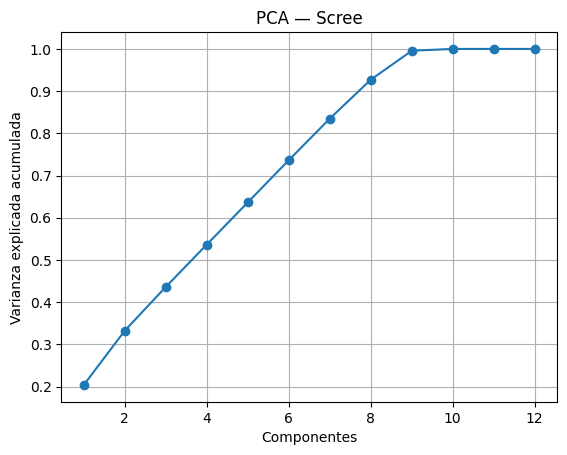

,PC1,PC2,PC3,PC4,PC5
mes,0.673665,-0.173046,-0.066012,6.164667e-04,2.935779e-03
trimestre,0.671994,-0.175652,-0.068305,-6.860164e-04,3.766915e-03
id_estado_del_procedimiento,-0.222853,-0.610469,-0.248287,3.878650e-04,6.930877e-03
codigo_entidad,0.177120,0.639467,0.233096,9.004719e-02,5.888700e-03
dia,-0.108225,0.026246,0.288784,-7.242739e-02,3.401523e-02
visualizaciones_del,0.032763,-0.332833,0.557620,8.521118e-02,-1.415421e-03
numero_de_lotes,-0.021525,-0.108065,0.225018,9.110691e-01,-3.387834e-02
proveedores_invitados,0.017652,-0.185639,0.655734,-3.847307e-01,8.588279e-03
precio_base,-0.001723,-0.001264,-0.005438,3.401233e-02,9.150735e-01
valor_total_adjudicacion,0.001039,-0.001597,-0.003166,1.273878e-02,4.001929e-01


In [47]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# === PCA (solo numéricas) ===
Xnum = X[num_cols].copy()
Xnum = Xnum.dropna(axis=1, how="all")
Xnum = Xnum.fillna(Xnum.median()) if not Xnum.empty else Xnum
pca_report = {}
if not Xnum.empty and Xnum.shape[1] >= 2:
    Z = StandardScaler().fit_transform(Xnum)
    pca = PCA().fit(Z)
    evr = pca.explained_variance_ratio_
    pca_report["explained_variance_ratio_"] = evr
    # Scree plot
    plt.figure(); plt.plot(np.arange(1,len(evr)+1), np.cumsum(evr), marker="o")
    plt.xlabel("Componentes"); plt.ylabel("Varianza explicada acumulada")
    plt.title("PCA — Scree"); plt.grid(True); plt.show()
    # Cargas principales (componentes)
    loadings = pd.DataFrame(pca.components_.T, index=Xnum.columns,
                            columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])])
    display(loadings.iloc[:, :5].sort_values("PC1", key=np.abs, ascending=False).head(15))
    loadings.to_csv(f"{OUT_DIR}/pca_loadings.csv")



In [51]:
# ==== EFA ROBUSTO (KMO, Bartlett, FactorAnalyzer varimax) ====
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

# ---------- preparar insumos ----------
if 'X' not in globals():
    X = df.copy()  # usa df si X no existe
if 'num_cols' not in globals() or not num_cols:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
OUT_DIR = OUT_DIR if 'OUT_DIR' in globals() else "/content"

# ---------- 1) base numérica y limpieza básica ----------
Xnum = X[num_cols].copy()
# Inf -> NaN
Xnum = Xnum.replace([np.inf, -np.inf], np.nan)

# quitar columnas con demasiados NaN (≥40% faltantes)
min_non_null = int(0.60 * len(Xnum))  # al menos 60% observaciones
keep = [c for c in Xnum.columns if Xnum[c].notna().sum() >= min_non_null]
Xnum = Xnum[keep]

# quitar varianza cero (evita std=0)
std0 = Xnum.std(skipna=True)
Xnum = Xnum.loc[:, std0 > 0]

# si quedó muy poco, abortar con mensaje claro
if Xnum.shape[1] < 2 or len(Xnum) < Xnum.shape[1] + 5:
    print("EFA omitido: pocas variables o filas insuficientes tras limpieza.",
          f"filas={len(Xnum)}, vars={Xnum.shape[1]}")
else:
    # ---------- 2) imputación mediana ----------
    Ximp = Xnum.copy()
    for c in Ximp.columns:
        med = Ximp[c].median(skipna=True)
        Ximp[c] = Ximp[c].fillna(med)

    # quitar colinealidad casi perfecta (|r| >= 0.99)
    corr = Ximp.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
    drop_cols = [col for col in upper.columns if (upper[col] >= 0.99).any()]
    if drop_cols:
        Ximp = Ximp.drop(columns=drop_cols)

    # check de nuevo
    if Ximp.shape[1] < 2:
        print("EFA omitido: tras remover colinealidad quedaron <2 variables.")
    else:
        # ---------- 3) estandarizar ----------
        Z = StandardScaler().fit_transform(Ximp)
        Zdf = pd.DataFrame(Z, columns=Ximp.columns)

        # ---------- 4) KMO y Bartlett (con reintento si salen NaN) ----------
        def kmo_bartlett_safe(D: pd.DataFrame):
            kmo_all, kmo_model = calculate_kmo(D)
            bart_chi2, bart_p = calculate_bartlett_sphericity(D)
            return float(kmo_model), float(bart_chi2), float(bart_p)

        try:
            kmo_model, bart_chi2, bart_p = kmo_bartlett_safe(Zdf)
        except Exception:
            kmo_model = np.nan; bart_chi2 = np.nan; bart_p = np.nan

        # si KMO NaN o muy bajo, aflojar más colinealidad (umbral 0.95) y reintentar
        if not np.isfinite(kmo_model) or np.isnan(kmo_model):
            corr2 = Zdf.corr().abs()
            upper2 = corr2.where(np.triu(np.ones(corr2.shape), 1).astype(bool))
            drop_cols2 = [col for col in upper2.columns if (upper2[col] >= 0.95).any()]
            if drop_cols2:
                Zdf = Zdf.drop(columns=drop_cols2, errors='ignore')
                # si quedan <2 variables, abortar
                if Zdf.shape[1] >= 2:
                    try:
                        kmo_model, bart_chi2, bart_p = kmo_bartlett_safe(Zdf)
                    except Exception:
                        pass

        print(f"KMO={kmo_model if np.isfinite(kmo_model) else float('nan'):.3f} "
              f"| Bartlett chi2={bart_chi2 if np.isfinite(bart_chi2) else float('nan'):.1f}, "
              f"p={bart_p if np.isfinite(bart_p) else float('nan'):.3g}")

        if (not np.isfinite(kmo_model)) or Zdf.shape[1] < 2:
            print("EFA abortada: matriz casi singular o muy pocas variables tras el saneo.")
        else:
            # ---------- 5) elegir número de factores (Kaiser acotado) ----------
            pca_tmp = PCA().fit(Zdf.values)
            kaiser = int((pca_tmp.explained_variance_ > 1.0).sum())
            n_factors = max(1, min(6, Zdf.shape[1] - 1, (kaiser if kaiser > 0 else 2)))
            print(f"n_factors seleccionado: {n_factors}")

            # ---------- 6) FactorAnalyzer (varimax, método ML) ----------
            fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='ml')
            fa.fit(Zdf.values)  # datos completos, sin NaN/Inf
            loads = pd.DataFrame(fa.loadings_, index=Zdf.columns,
                                 columns=[f"F{i+1}" for i in range(n_factors)])

            # ordenar por contribución absoluta al primer factor
            with pd.option_context('display.max_rows', None, 'display.max_columns', None):
                display(loads.sort_values(loads.columns[0], key=lambda s: s.abs(), ascending=False).head(30))

            out_path = f"{OUT_DIR}/efa_loadings_{n_factors}f.csv"
            loads.to_csv(out_path)
            print("Cargas factoriales guardadas en:", out_path)



KMO=0.517 | Bartlett chi2=3730836.9, p=0
n_factors seleccionado: 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,F1,F2,F3,F4,F5,F6
mes,0.989843,0.080673,0.088779,-0.006775,-0.002070,0.026570
trimestre,0.951552,0.077677,0.075880,-0.013975,0.270465,0.065949
id_estado_del_procedimiento,-0.090524,-0.565942,-0.013203,0.151777,-0.020966,0.160136
dia,-0.087353,-0.010799,0.016236,0.007394,0.034160,0.006714
codigo_entidad,0.048159,0.575157,-0.106117,-0.002137,-0.022808,0.112542
visualizaciones_del,0.017774,-0.026629,0.337249,0.298294,0.007105,0.011708
numero_de_lotes,-0.008042,-0.019028,-0.006079,0.115029,0.000499,-0.000648
proveedores_invitados,0.002177,-0.023038,0.207847,-0.023696,0.003591,-0.004489
precio_base,-0.001588,-0.000366,-0.000064,-0.000820,-0.001970,0.018025
valor_total_adjudicacion,0.000591,-0.000043,-0.000036,0.000258,0.000603,0.004782


Cargas factoriales guardadas en: /content/drive/MyDrive/secop_out/efa_loadings_6f.csv


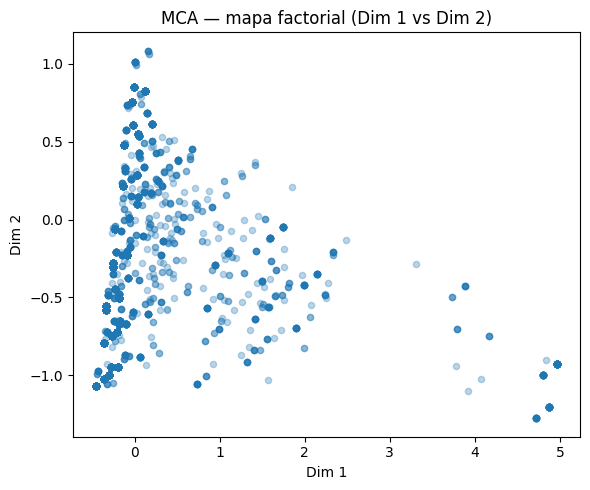

In [54]:
# Después de: coords = mca_fit.transform(plot_df)

# Asegurar DataFrame
import pandas as pd
import matplotlib.pyplot as plt

if not isinstance(coords, pd.DataFrame):
    coords = pd.DataFrame(coords, index=plot_df.index)

# ¿hay al menos 2 dimensiones para graficar?
if coords.shape[1] >= 2:
    # tomar las dos primeras columnas por posición y renombrar
    coords_2d = coords.iloc[:, :2].copy()
    coords_2d.columns = ["Dim1", "Dim2"]

    ax = coords_2d.plot(kind="scatter", x="Dim1", y="Dim2", alpha=0.3, figsize=(6,5))
    ax.set_title("MCA — mapa factorial (Dim 1 vs Dim 2)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    plt.tight_layout()
    plt.show()
else:
    print("MCA: menos de 2 dimensiones; no se grafica.")
